# １章３節２項 アンテナパターン

## 概要
レーダーのアンテナパターンの可視化です。

## 使用データ

| 項目 | 使用データなし |
| ---- | ---- | 

In [ ]:
import os
import numpy as np
import warnings
import tifffile
import cv2

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt


PATH_OUTPUT = os.path.join('output', f'1_3_2')
os.makedirs(PATH_OUTPUT, exist_ok=True)

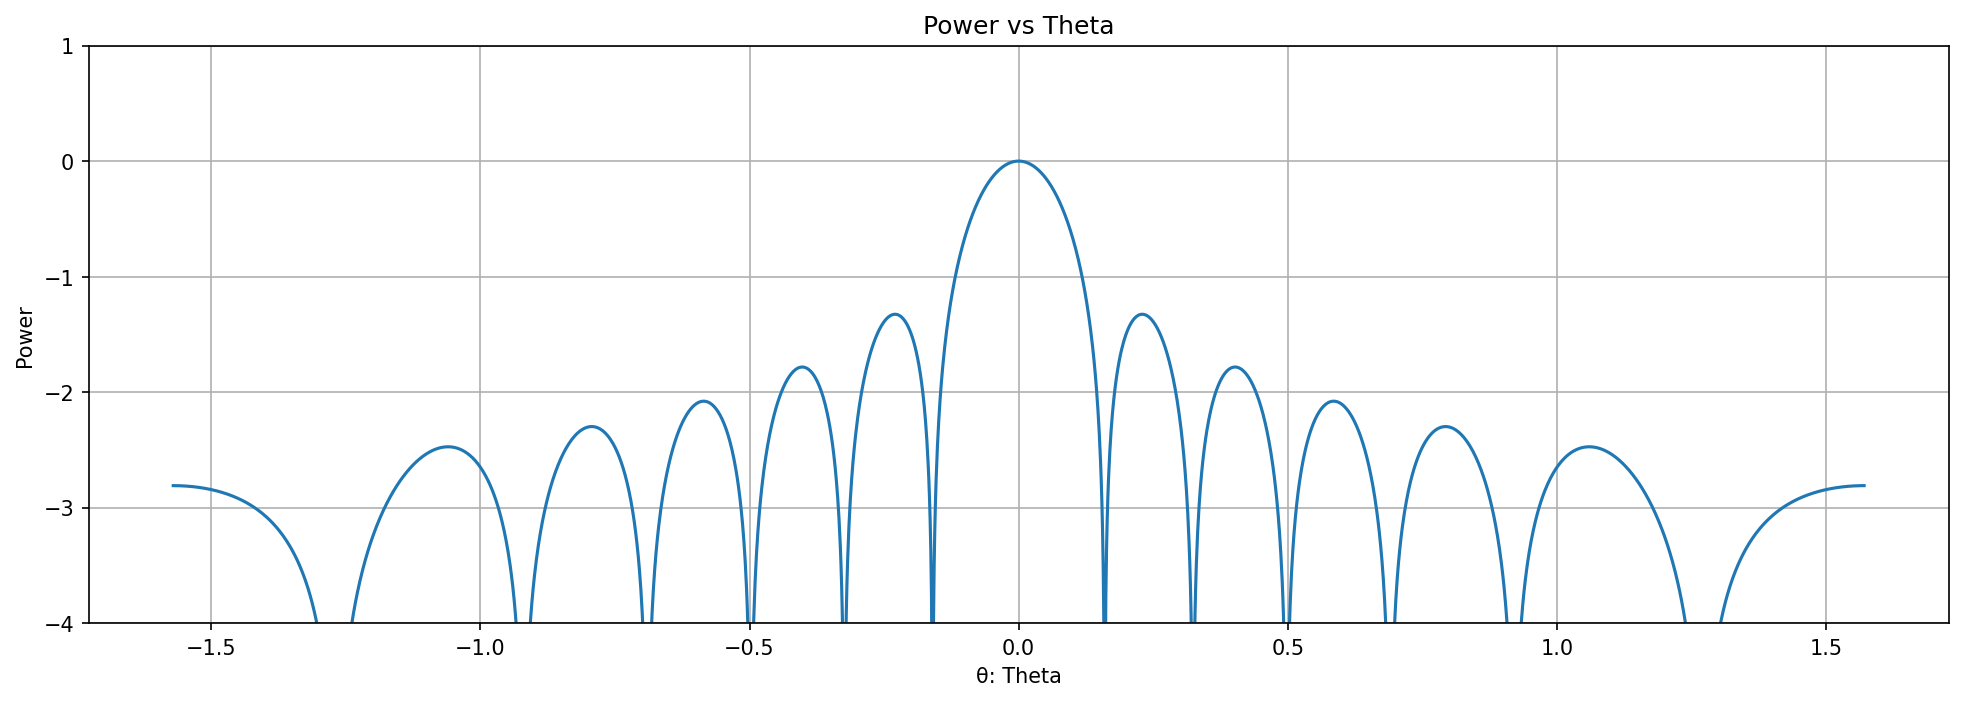

In [4]:
D = 1
E = 1
r = 2
K = 2 * np.pi * r
scale = 1

NUM_SAMPLE = 2560 + 1
theta = np.linspace(-np.pi/2, np.pi/2, NUM_SAMPLE)

P = np.square(E) * np.square(np.sinc(K * D * np.sin(theta) / 2))
P_dB = scale * np.log10(P)

plt.figure(figsize=(16, 5), facecolor='white', dpi=150, edgecolor='k')
plt.plot(theta, P_dB)
plt.xlabel('θ: Theta')
plt.ylabel('Power')
plt.ylim(-4, 1)
plt.title('Power vs Theta')
plt.grid()
plt.savefig(os.path.join(PATH_OUTPUT, 'Power_vs_theta.png'))
plt.show();plt.clf();plt.close()

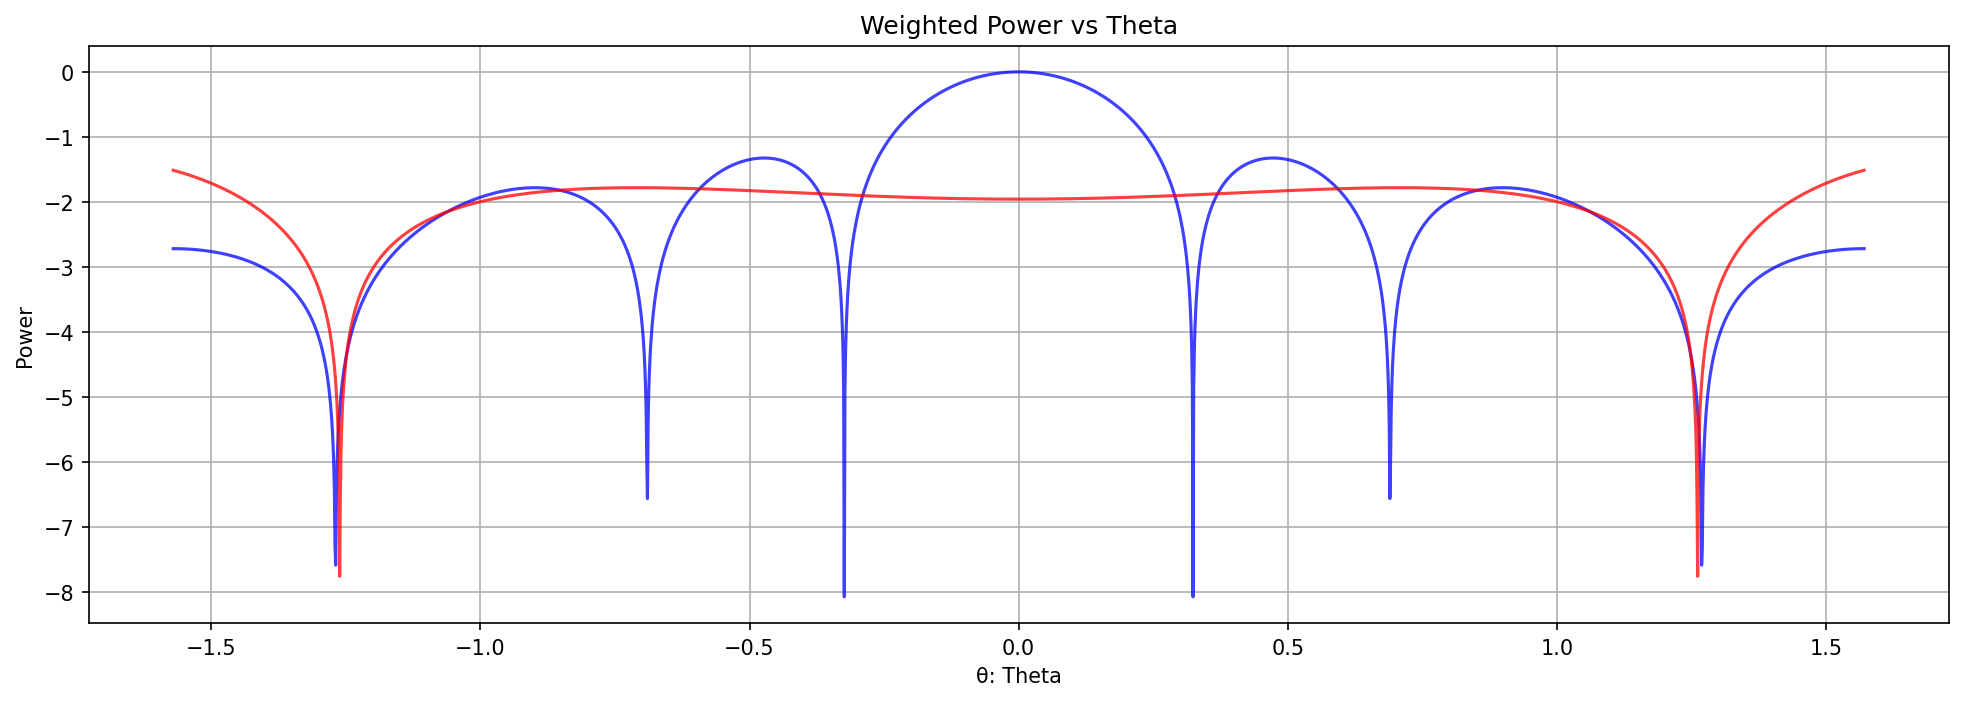

In [3]:
def wighted_function(theta, b=0.55, w=0.46):
    return b + w * np.cos(theta)

P_w = np.square(E) * np.square(np.sinc(K * D * np.sin(wighted_function(theta)) / 2))
P_dB_w = scale * np.log10(P_w)

plt.figure(figsize=(16, 5), facecolor='white', dpi=150, edgecolor='k')
plt.plot(theta, P_dB, label='Power', color='blue', alpha=0.75)
plt.plot(theta, P_dB_w, label='Weighted Power', color='red', alpha=0.75)
plt.xlabel('θ: Theta')
plt.ylabel('Power')
# plt.ylim(-4, 1)
plt.title('Weighted Power vs Theta')
plt.grid()
plt.savefig(os.path.join(PATH_OUTPUT, 'Power_vs_theta_weight.png'))
plt.show();plt.clf();plt.close()